# Multi-Agent Systems in LangGraph — Native Supervisor Pattern

**Raz Systems · Agentic AI Engineering Curriculum**

---

This notebook builds the **same kind of system** as the CrewAI multi-agent notebook (`multiagent_crewai_bangalore.ipynb`) — a supervisor coordinating specialized agents toward one shared goal — but using **LangGraph itself**, with no separate multi-agent framework.

**Why this matters:** LangGraph doesn't need CrewAI (or any other library) bolted on to do multi-agent work. Multiple agents are just **multiple nodes in the same graph** — the same `StateGraph` / `add_node` machinery from every other notebook in this curriculum, applied to coordinating whole agents instead of single processing steps.

**A note on approach:** there's a convenience package called `langgraph-supervisor` that wraps this pattern into a one-line `create_supervisor(...)` call. As of early 2026, the LangGraph team itself recommends building the supervisor pattern manually with tool-calling and `Command` objects instead, for most use cases — it gives more control and is easier to debug, and it keeps the system fully visible as an inspectable graph rather than hidden inside a helper function. This notebook follows that current recommendation.

**Worked example (same topic as the CrewAI notebook, for direct comparison):** *Bangalore's tech industry and startup ecosystem*.

## The architecture

Same supervisor/network distinction as the MachineLearningMastery article and the CrewAI notebook:

- **Supervisor architecture** (what we build here) — one supervisor node decides which specialist agent acts next.
- **Network architecture** — agents hand off to each other directly, with no central coordinator.

**Three specialist agents** (trimmed from the CrewAI notebook's four, to keep the graph readable — adding a fourth is a one-line extension, shown at the end):

1. **Researcher agent** — searches the web (via Serper) for facts about the topic
2. **Analyst agent** — extracts and ranks the most significant trends from the research
3. **Writer agent** — drafts a structured report from the research + analysis

**One supervisor node** — an LLM call that looks at the conversation so far and decides which specialist should act next, or whether the report is complete.

## How this differs structurally from the CrewAI version

| | CrewAI (previous notebook) | LangGraph (this notebook) |
|---|---|---|
| Agent definition | `Agent(role=..., goal=..., backstory=...)` | `create_agent(model, tools, system_prompt=...)` — itself a small compiled graph |
| Coordination | `Crew(process=Process.hierarchical, manager_agent=...)` | A `supervisor` node returning `Command(goto=..., update=...)` |
| Control flow visibility | Delegated to the manager agent's own reasoning, not inspectable as a diagram | A real `StateGraph` you can draw, inspect, and modify node by node |
| Shared state | Implicit, managed by CrewAI's `Crew` runtime | Explicit `MessagesState` — the same accumulating message list pattern from the ReAct notebooks |

## 1. Setup

In [2]:
import os
from typing import Literal

import requests
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command

load_dotenv()

SERPER_API_KEY = os.getenv("SERPER_API_KEY")

llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))

## 2. The search tool

Same Serper pattern used throughout the rest of the Raz Systems curriculum (`search_flights` / `search_hotels` in the LangGraph travel-agent notebooks, `SerperDevTool` in the CrewAI notebook). Here it's just a plain Python function with a type hint and a docstring — `create_agent` reads the docstring to decide when the agent should call it, the same mechanism you've already seen with `@tool`-decorated functions.

In [3]:
def search_web(query: str) -> str:
    """Search the web using Serper and return the top results as readable text. Useful for finding current, factual information on any topic."""
    response = requests.post(
        "https://google.serper.dev/search",
        json={"q": query},
        headers={"X-API-KEY": SERPER_API_KEY, "Content-Type": "application/json"},
        timeout=15,
    )
    data = response.json()

    results = []
    for item in data.get("organic", [])[:5]:
        results.append(f"Title: {item.get('title')}\nSnippet: {item.get('snippet')}")

    return "\n\n".join(results) or "No results found."


# Quick sanity check (requires a valid SERPER_API_KEY)
print(search_web("Bangalore tech industry startups")[:400])

Title: Top Tech Startups in Bangalore Urban, India in 2026
Snippet: Top Tech Startups in Bangalore Urban, India in 2026 · Rippling · Netskope · Fireflies.ai · Swym · Marmeto · G2 · MarcoPolo Learning · Gyrus.AI.

Title: Top 29 Bangalore Startups — Newly Funded & Hiring
Snippet: Track new startups funded by top investors. Powerful filters. Updates daily. · Innoviti Solutions · Rupeek · Byjus · Perf


## 3. The specialist agents

Each agent here is built with `create_agent(model, tools, system_prompt=..., name=...)` — and each one is, under the hood, **its own small compiled LangGraph graph** (a ReAct-style loop, just like the Part 1/2 notebooks, prebuilt for you). That's worth sitting with for a second: in this architecture, a "multi-agent system" is literally a graph whose nodes are themselves graphs.

Only the **researcher** gets `tools=[search_web]` — same principle as giving `search_flights` only to the relevant node in the travel-agent notebooks, or `SearchTool` only to the web researcher in the CrewAI notebook. The analyst and writer work purely from what's already in the conversation.

In [4]:
researcher_agent = create_agent(
    llm,
    tools=[search_web],
    system_prompt=(
        "You are a Web Research Specialist. Given a topic, search the web to find the most recent, "
        "impactful, and relevant facts — key developments, notable companies, and statistics. "
        "Reply with a structured list of 5-7 findings, each with a brief supporting detail."
    ),
    name="researcher",
)

analyst_agent = create_agent(
    llm,
    tools=[],
    system_prompt=(
        "You are an Insight Synthesizer. Given research findings already in the conversation, "
        "extract the most significant trends and rank them by impact, growth potential, and uniqueness. "
        "Reply with a table ranking trends, each with a concise description."
    ),
    name="analyst",
)

writer_agent = create_agent(
    llm,
    tools=[],
    system_prompt=(
        "You are a Narrative Architect. Given research findings and trend analysis already in the "
        "conversation, draft a structured, professional report with sections for Introduction, "
        "Trends Overview, Analysis, and Recommendations."
    ),
    name="writer",
)

print("✅ 3 specialist agents created — each is its own compiled graph")

✅ 3 specialist agents created — each is its own compiled graph


## 4. The supervisor node

This is the one piece that has no equivalent anywhere else in the curriculum until now: a node whose entire job is **deciding which other node runs next**, using its own LLM call rather than a hardcoded rule (compare to `decide()` in the travel agent, which is plain Python — the supervisor here is the LLM-powered analog, same relationship as Part 1 vs. Part 2 of the ReAct notebooks).

The supervisor returns a **`Command`** object — this is LangGraph's mechanism for a node to simultaneously (1) say where to go next (`goto`) and (2) update shared state (`update`), in a single return value. This is different from the `router()` pattern in the ReAct notebooks, where deciding-where-to-go and updating-state were two separate steps (a node returns a state update, then a *separate* router function decides where to go). `Command` fuses both into the node itself — useful exactly when the same piece of logic (here, the supervisor's reasoning) needs to do both jobs at once.

In [5]:
SUPERVISOR_PROMPT = """You are the Workflow Maestro, supervising a research team with three specialists:

- researcher: searches the web for facts about the topic
- analyst: extracts and ranks trends from research already gathered
- writer: drafts a structured report from research and analysis already gathered

Look at the conversation so far and decide which specialist should act next.
- If no research has been done yet, choose researcher.
- If research exists but no trend analysis, choose analyst.
- If research and analysis exist but no report draft, choose writer.
- If a full report draft already exists, respond with exactly: DONE

Respond with EXACTLY ONE of: researcher, analyst, writer, DONE — nothing else.
"""

def supervisor_node(state: MessagesState) -> Command[Literal["researcher", "analyst", "writer", "__end__"]]:
    history = "\n\n".join(f"[{m.type}] {m.content}" for m in state["messages"])

    decision = llm.invoke([
        {"role": "system", "content": SUPERVISOR_PROMPT},
        {"role": "user", "content": f"Conversation so far:\n\n{history}\n\nWho should act next?"},
    ])

    choice = decision.content.strip().lower()
    print(f"\n🧑‍💼 SUPERVISOR decision: {choice}")

    if "done" in choice:
        return Command(goto=END)
    if "researcher" in choice:
        return Command(goto="researcher")
    if "analyst" in choice:
        return Command(goto="analyst")
    if "writer" in choice:
        return Command(goto="writer")

    # Fallback if the LLM's response doesn't match any expected keyword
    print("⚠️ Unrecognized supervisor decision, defaulting to researcher")
    return Command(goto="researcher")

## 5. The worker nodes — wrapping each agent for the graph

Each specialist agent is already a compiled graph (from `create_agent`), but it expects to be `.invoke()`-d with its own message list and to return its own result — it doesn't know about `Command` or how to route back to the supervisor. These wrapper nodes bridge that gap: run the agent, then explicitly hand control back to `supervisor` via `Command`.

This is the same bridging idea as `self._delegate.on_messages(...)` from earlier in the curriculum — a wrapper node whose job is purely to call a "real" agent and adapt its output to the surrounding graph's calling convention.

In [6]:
def researcher_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = researcher_agent.invoke(state)
    return Command(goto="supervisor", update={"messages": result["messages"]})


def analyst_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = analyst_agent.invoke(state)
    return Command(goto="supervisor", update={"messages": result["messages"]})


def writer_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = writer_agent.invoke(state)
    return Command(goto="supervisor", update={"messages": result["messages"]})

## 6. Assemble the graph

Notice what's absent compared to every earlier notebook: **no `add_edge` and no `add_conditional_edges` calls at all.** Every routing decision in this graph is made *inside* the nodes themselves via the `Command` objects they return — `add_node` is the only graph-building call needed. This is a direct consequence of using `Command`: it replaces the separate edge-wiring step with routing logic embedded in each node's return value.

In [7]:
builder = StateGraph(MessagesState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", researcher_node)
builder.add_node("analyst", analyst_node)
builder.add_node("writer", writer_node)

builder.add_edge(START, "supervisor")

app = builder.compile()

print("✅ Graph compiled —", list(app.get_graph().nodes.keys()))

✅ Graph compiled — ['__start__', 'supervisor', 'researcher', 'analyst', 'writer', '__end__']


## 7. (Optional) Visualize the graph

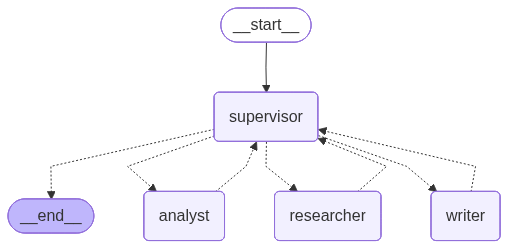

In [8]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization unavailable in this environment:", e)
    print(app.get_graph().draw_mermaid())

## 8. Run it — Bangalore's tech industry and startup ecosystem

Same topic as the CrewAI notebook. Watch the supervisor's decisions in the printed trace — you'll see it route researcher → analyst → writer → DONE, deciding that sequence itself rather than following a hardcoded order.

In [9]:
initial_state = {
    "messages": [
        HumanMessage(content="Produce a report on Bangalore's tech industry and startup ecosystem.")
    ]
}

print("🚀 STARTING LANGGRAPH MULTI-AGENT SUPERVISOR\n" + "=" * 60)

result = app.invoke(initial_state, config={"recursion_limit": 25})

print("\n" + "=" * 60)
print("✅ DONE\n")
print("===== FINAL REPORT =====\n")
print(result["messages"][-1].content)

🚀 STARTING LANGGRAPH MULTI-AGENT SUPERVISOR

🧑‍💼 SUPERVISOR decision: researcher

🧑‍💼 SUPERVISOR decision: done

✅ DONE

===== FINAL REPORT =====

### Report on Bangalore's Tech Industry and Startup Ecosystem (2023)

1. **Investment and Growth Trends**
   - Bangalore, known as Bengaluru, attracts 33% of total startup funding in India, equivalent to approximately $3.9 billion. This positions it as the foremost hub for technology startups in the country, significantly outpacing Mumbai, which accounted for 21% or $2.4 billion.

2. **Startup Ecosystem Size and Diversity**
   - The city is home to around 3,834 startups, and Karnataka boasts a total of 21,000 startups, making it one of India’s largest and most mature ecosystems. Bangalore's diverse economy supports a range of sectors, particularly high-growth companies like Byju's (edtech), Swiggy (food delivery), and Ola (ride-hailing).

3. **Focus on Artificial Intelligence (AI)**
   - Bengaluru leads in AI startup funding, attracting appr

## 9. Inspect the full pipeline

Because everything lives in one shared `MessagesState`, you can walk through every message any agent produced, in order — useful for debugging which specialist introduced an issue, exactly like inspecting `crew_output.tasks_output` in the CrewAI notebook, but as a plain list you already know how to work with from every ReAct notebook in this curriculum.

In [10]:
for i, m in enumerate(result["messages"]):
    label = getattr(m, "name", None) or m.type
    print(f"\n--- Message {i} ({label}) ---")
    content = m.content if isinstance(m.content, str) else str(m.content)
    print(content[:300], "..." if len(content) > 300 else "")


--- Message 0 (human) ---
Produce a report on Bangalore's tech industry and startup ecosystem. 

--- Message 1 (researcher) ---
 

--- Message 2 (search_web) ---
Title: Bengaluru-Karnataka - Startup Genome
Snippet: The state has captured about 46% of all VC investments into Indian startups, playing a key role in a national ecosystem that has created over 140,000 technology ...

Title: Bengaluru isn't just India's tech capital, it's now among the top 5 AI ... ...

--- Message 3 (researcher) ---
 

--- Message 4 (search_web) ---
Title: The Global Startup Ecosystem Report 2025
Snippet: Bengaluru startups raised $268 million in seed funding a 26% increase from the previous year. growing by 4% year-over-year to hit 114.

Title: Bengaluru's Startup Ecosystem Shifts to Execution Over ...
Snippet: Karnataka's startup engine looke ...

--- Message 5 (search_web) ---
Title: Bengaluru-Karnataka
Snippet: Bengaluru attracts 58% of India's AI startup funding, with ~$1.5B raised since 2020, of which

## 10. Extending: adding a fourth agent (proofreader)

To match the CrewAI notebook's four-agent system exactly, add a `proofreader` agent the same way as the other three:

```python
proofreader_agent = create_agent(
    llm,
    tools=[],
    system_prompt=(
        "You are a Polisher of Excellence. Given a report draft already in the conversation, "
        "refine it for grammatical accuracy, coherence, and formatting. Reply with the final, "
        "polished report."
    ),
    name="proofreader",
)

def proofreader_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    result = proofreader_agent.invoke(state)
    return Command(goto="supervisor", update={"messages": result["messages"]})

builder.add_node("proofreader", proofreader_node)
```

...and update `SUPERVISOR_PROMPT` to mention the new specialist and when to route to it (after `writer`, before `DONE`). Notice that adding a worker here means writing one new agent + one new wrapper node + one routing rule in a prompt — there's no equivalent of touching `Crew(agents=[...])`'s list in five different places, because there's only one place (`SUPERVISOR_PROMPT`) that knows the roster.

## 11. What this notebook demonstrates, and how it compares

**The core point:** LangGraph doesn't need an external multi-agent framework. The same primitives you've used throughout this curriculum — `StateGraph`, `add_node`, a shared state object — are sufficient to build a supervisor architecture. The only genuinely new primitive introduced here is `Command`, which fuses "what should happen to state" and "where should we go next" into one return value, useful specifically when a single piece of reasoning (the supervisor's LLM call) needs to answer both questions at once.

| | LangGraph (this notebook) | CrewAI (previous notebook) |
|---|---|---|
| Who decides "what's next" | The supervisor node's own LLM call, fully visible as Python code you wrote | The manager agent's internal reasoning, inside CrewAI's own runtime |
| Control flow visibility | A real graph — `app.get_graph()` draws it | Not a graph you can draw; it's whatever the manager agent decided at runtime |
| Where state lives | One explicit `MessagesState`, the same pattern as every ReAct notebook | Managed internally by `Crew` |
| Extending with a new agent | New `create_agent(...)` + wrapper node + one line in the supervisor's prompt | New `Agent(...)` + add it to `Crew(agents=[...])` and to whichever tasks need it |
| Best fit | When you want the coordination logic itself to be inspectable, debuggable Python | When you want agent roles described in natural language and don't need to see the graph |

Both produce the same kind of system — specialized agents collaborating under a supervisor toward one goal. The difference is entirely in how much of the coordination machinery is visible to you versus delegated to a framework's internals. Given everything else in this curriculum has favored explicit, inspectable graphs (V1/V3 travel agent, the ReAct notebooks), this LangGraph-native version is the one that stays most consistent with that approach.